# TD3 Victor Bouvier d'Acher

In [1]:
from skimage import data
from skimage.color import rgb2gray, label2rgb
from skimage.transform import resize, rotate
from skimage.feature import hog, canny, corner_harris, corner_peaks, Cascade
from skimage.segmentation import slic
from skimage.filters import gaussian
from skimage.restoration import inpaint, denoise_bilateral, denoise_tv_chambolle
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib import patches
import cv2
import numpy as np

In [2]:
def show_image(image, title='Image', cmap_type='gray'):
    plt.imshow(image, cmap=cmap_type)
    plt.title(title)
    plt.axis('off')
    plt.show()  

def plot_comparison(original, filtered, title,title_filtered):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 6), sharex=True,
    sharey=True)
    ax1.imshow(original,cmap='gray' )
    ax1.set_title(title)
    ax1.axis('off')
    ax2.imshow(filtered,cmap='gray' )
    ax2.set_title(title_filtered)
    ax2.axis('off')

def show_image_contour(image, contours):
    plt.figure()
    for n, contour in enumerate(contours):
        plt.plot(contour[:, 1], contour[:, 0], linewidth=3)
    plt.imshow(image, interpolation='nearest', cmap='gray_r')
    plt.title('Contours')
    plt.axis('off')

def show_image_with_corners(image, coords, title="Corners detected"):
    plt.imshow(image, interpolation='nearest', cmap='gray')
    plt.title(title)
    plt.plot(coords[:, 1], coords[:, 0], '+r', markersize=15)
    plt.axis('off')
    plt.show()


def plot_comparison_with_corners(image,coords1,coords2 , title1,title2):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 6), sharex=True,
    sharey=True)
    ax1.imshow(image, interpolation='nearest', cmap='gray' )
    ax1.set_title(title1)
    ax1.plot(coords1[:, 1], coords1[:, 0], '+r', markersize=15)
    ax1.axis('off')
    ax2.imshow(image, interpolation='nearest', cmap='gray')
    ax2.plot(coords2[:, 1], coords2[:, 0], '+r', markersize=15)
    ax2.set_title(title2)
    ax2.axis('off')

def crop_face(result, detected, title="Face detected"):
    for d in detected:
        print(d)
        rostro= result[d['r']:d['r']+d['width'], d['c']:d['c']+d['height']]

        plt.figure(figsize=(8, 6))
        plt.imshow(rostro)    
        plt.title(title)
        plt.axis('off')
        plt.show()

def show_detected_face(result, detected, title="Face image"):
    plt.figure()
    plt.imshow(result)
    img_desc = plt.gca()
    plt.set_cmap('gray')
    plt.title(title)
    plt.axis('off')

    for patch in detected:

        img_desc.add_patch(
            patches.Rectangle(
                (patch['c'], patch['r']),
                patch['width'],
                patch['height'],
                fill=False,
                color='r',
                linewidth=2)
        )
    plt.show()
    crop_face(result, detected)

def getFaceRectangle(image, d):
    ''' Extracts the face from the image using the coordinates of the detected image '''
    # X and Y starting points of the face rectangle
    x, y  = d['r'], d['c']

    # The width and height of the face rectangle
    width, height = d['r'] + d['width'],  d['c'] + d['height']

    # Extract the detected face
    face= image[ x:width, y:height]
    return face

def mergeBlurryFace(original, gaussian_image, d):
     # X and Y starting points of the face rectangle
    x, y  = d['r'], d['c']
    # The width and height of the face rectangle
    width, height = d['r'] + d['width'],  d['c'] + d['height']

    original[ x:width, y:height] = gaussian_image
    return original


1. Exercice

shape of the image = (300, 175, 3)
shape of the resized image = (128, 64, 3)
Number of features =  (3780,)


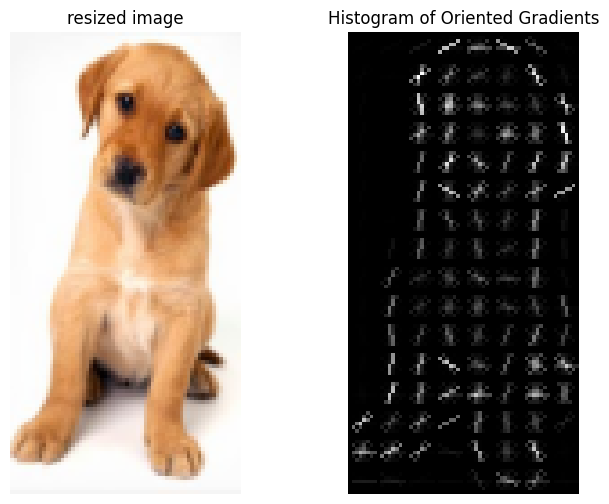

In [3]:
chien = mpimg.imread("puppy_image.jpeg")

print(f'shape of the image = {chien.shape}')

# resize this image into 128 x 64
image_resized = resize(chien, (128, 64), anti_aliasing=True)

# check the shape of the image one more time
print(f'shape of the resized image = {image_resized.shape}')

# Set 'visualize = True', to have the HOG image in return
fd, hog_image = hog(image_resized, orientations=9, pixels_per_cell=(8, 8), 
                    cells_per_block=(2, 2), visualize=True, channel_axis=-1)
                    
# print the shape of fd
print("Number of features = ", fd.shape)

plot_comparison(image_resized ,hog_image,'resized image','Histogram of Oriented Gradients')


2. Exercice

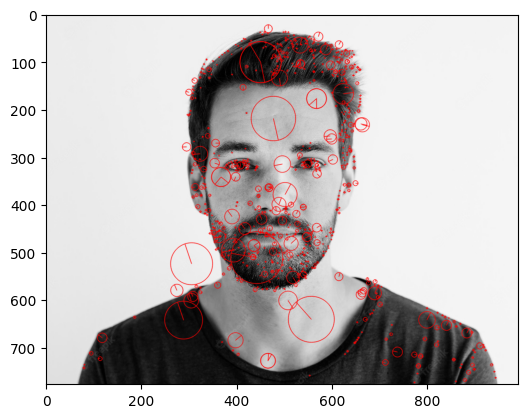

In [4]:
mec = mpimg.imread("homme.jpg")

# input image is converted to gray scale image
gray = cv2.cvtColor(mec ,cv2.COLOR_BGR2GRAY)

#create sift object
features = cv2.SIFT_create()

#calculate keypoints and their orientation
keypoints = features.detect(gray,None)

#plot keypoints on the image
key = cv2.drawKeypoints(gray ,keypoints,0, (255, 0, 0),
                                 flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.imshow(key)

plt.show()

3. Exercice

452 703
452 543
452 747


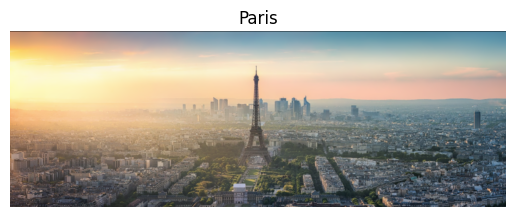

In [5]:
# declare an array containing the names of the 3 images
# paris1.jpeg, paris2.jpeg and paris3.jpeg
nom=["paris1.jpeg","paris2.jpeg","paris3.jpeg"]

# initialized a list of images
imgs = []

# loop over the names of the images
for i in range(len(nom)):
    # append to imgs the content of the images 
  imgs.append(mpimg.imread(nom[i]))
  # for each image resize it to 50 % 
  h = int(imgs[i].shape[0] / 2)
  w = int(imgs[i].shape[1] / 2)
  print(h, w)
  # use cv2.resize 
  imgs[i]=cv2.resize(imgs[i], (w, h), interpolation=cv2.INTER_AREA)
	
# stitch the images
stitchy=cv2.Stitcher.create()
(dummy,output)=stitchy.stitch(imgs)


# checking if the stitching procedure is successful
# .stitch() function returns a true value if stitching is
# done successfully
if dummy != cv2.STITCHER_OK:
	print("stitching ain't successful")
else:
  # Panorama is ready
  plt.imshow(output)
  plt.title("Paris")
  plt.axis('off')
  plt.show()  
  
 

4. Exercice

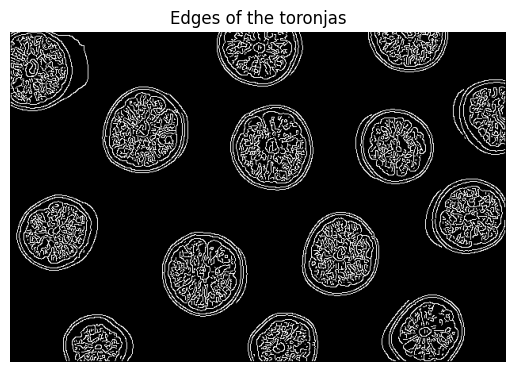

In [6]:
pamplemousse = mpimg.imread("toronjas.jpg")

gray_pamplemousse = rgb2gray(pamplemousse)

edge = canny(gray_pamplemousse)

show_image(edge, "Edges of the toronjas")

5. Exercice

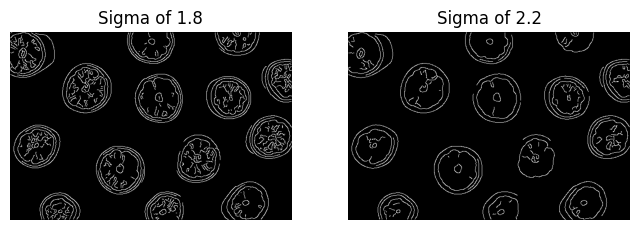

In [7]:

# Apply canny edge detector with a sigma of 1.8
edges_1_8 = canny(gray_pamplemousse, sigma=1.8)

# Apply canny edge detector with a sigma of 2.2
edges_2_2 = canny(gray_pamplemousse, sigma=2.2)


# Show resulting images
plot_comparison(edges_1_8, edges_2_2, "Sigma of 1.8","Sigma of 2.2")


6. Exercice

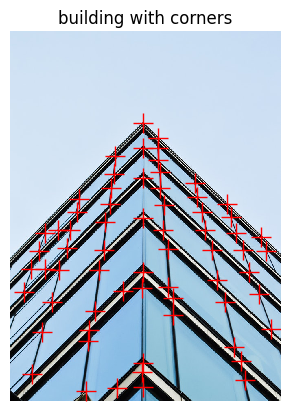

In [8]:
batiment = mpimg.imread("corners_building_top.jpg")

gray_batiment = rgb2gray(batiment)

corner_detector = corner_harris(gray_batiment)

coor = corner_peaks(corner_detector, min_distance=20, threshold_rel=0.02)

show_image_with_corners(image=batiment, coords=coor, title="building with corners")

7. Exercice

With a min_distance set to 10, we detect a total 89 corners in the image.
With a min_distance set to 60, we detect a total 20 corners in the image.


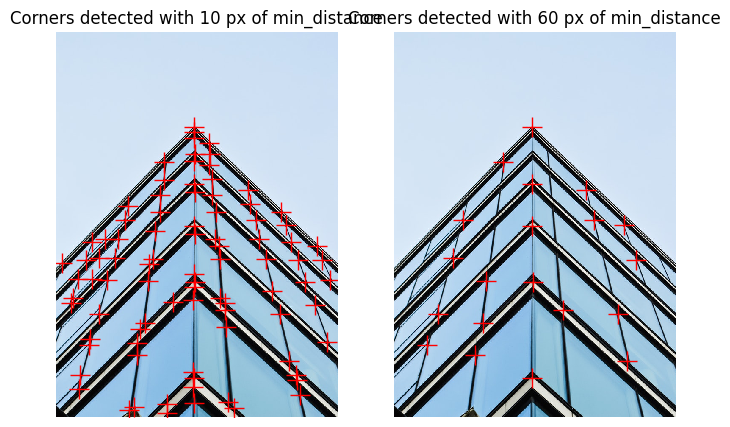

In [9]:
# Find the peaks with a min distance of 10 pixels
coords_w_min_10 = corner_peaks(corner_detector, min_distance=10, threshold_rel=0.02)
print("With a min_distance set to 10, we detect a total", len(coords_w_min_10), "corners in the image.")

# Find the peaks with a min distance of 60 pixels
coords_w_min_60 = corner_peaks(corner_detector, min_distance=60, threshold_rel=0.02)
print("With a min_distance set to 60, we detect a total", len(coords_w_min_60), "corners in the image.")


plot_comparison_with_corners(batiment,coords_w_min_10, coords_w_min_60, "Corners detected with 10 px of min_distance", "Corners detected with 60 px of min_distance")

8. Exercice

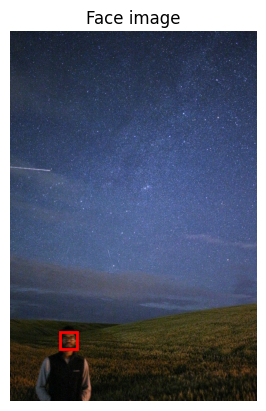

{'r': 773, 'c': 129, 'width': 43, 'height': 43}


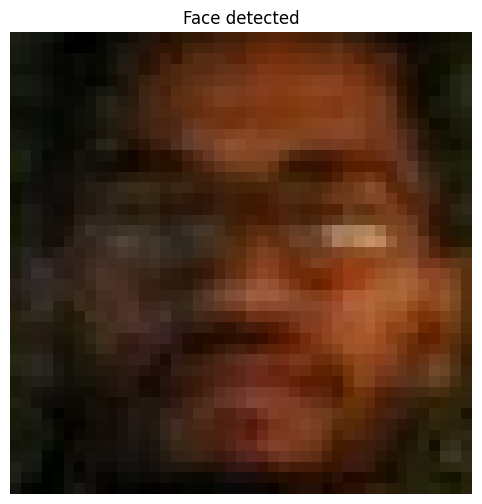

In [10]:
nuit = mpimg.imread("face_det3.jpg")

trained_file = data.lbp_frontal_face_cascade_filename()

# Initialize the detector cascade
detector = Cascade(trained_file)

# Detect faces with min and max size of searching window
detecte = detector.detect_multi_scale(img = nuit,
                                       scale_factor=1.2,
                                       step_ratio=1,
                                       min_size=(10, 10),
                                       max_size=(200, 200))

# Show the detected faces
show_detected_face(nuit, detecte)


9. Exercice

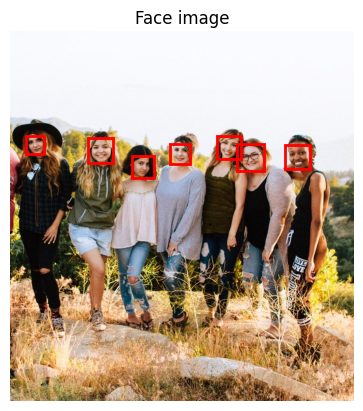

{'r': 202, 'c': 31, 'width': 35, 'height': 35}


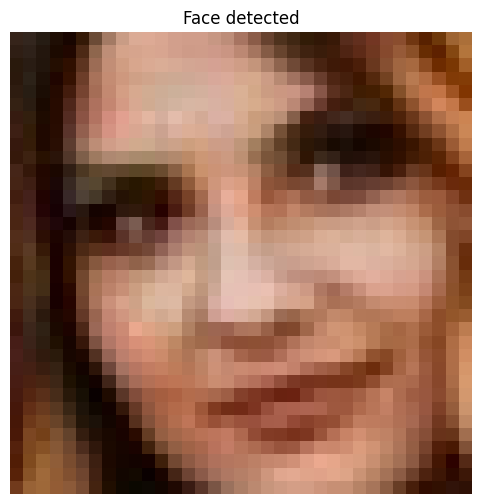

{'r': 217, 'c': 309, 'width': 39, 'height': 39}


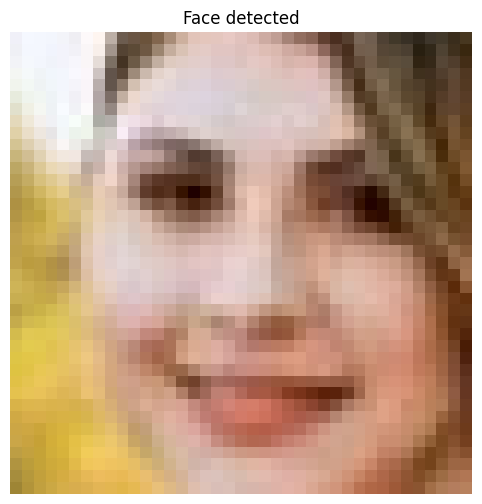

{'r': 202, 'c': 402, 'width': 45, 'height': 45}


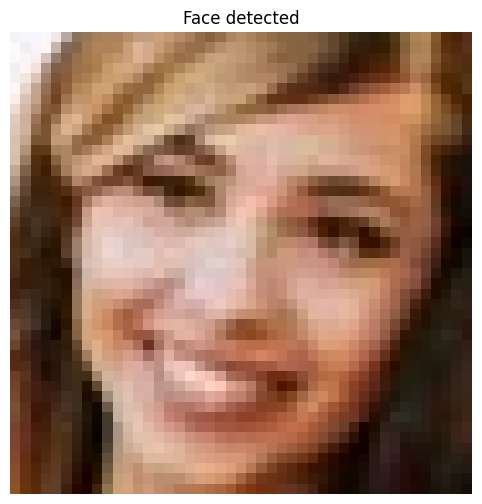

{'r': 206, 'c': 151, 'width': 49, 'height': 49}


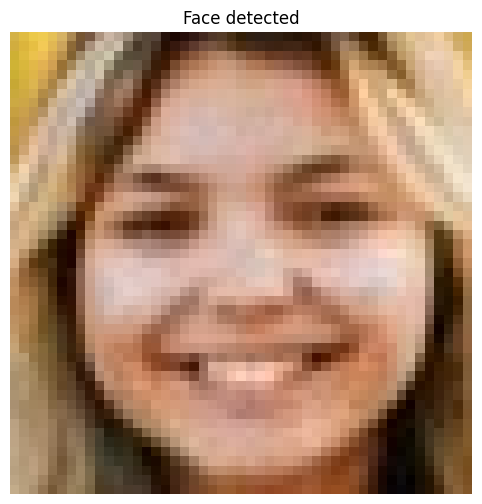

{'r': 219, 'c': 533, 'width': 48, 'height': 48}


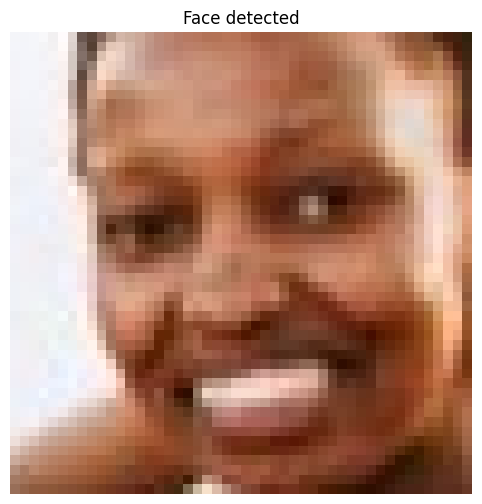

{'r': 218, 'c': 440, 'width': 52, 'height': 52}


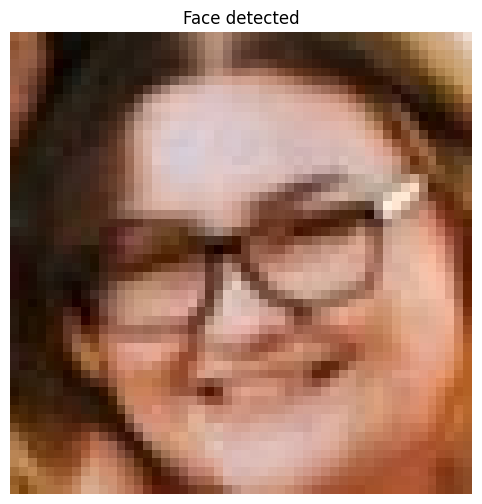

{'r': 241, 'c': 237, 'width': 42, 'height': 42}


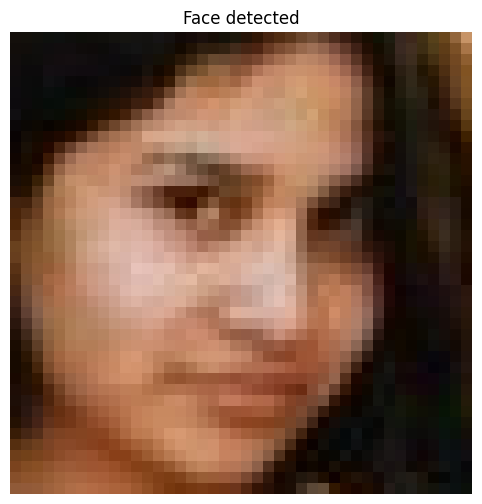

In [11]:
ami = mpimg.imread("face_det_friends22.jpg")

detect = detector.detect_multi_scale(img=ami,
                                       scale_factor=1.2,
                                       step_ratio=1,
                                       min_size=(10, 10),
                                       max_size=(200, 200))

show_detected_face(ami, detect)

10. Exercice

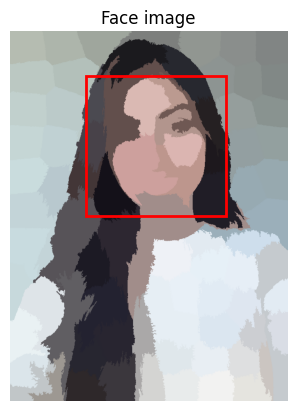

{'r': 105, 'c': 180, 'width': 334, 'height': 334}


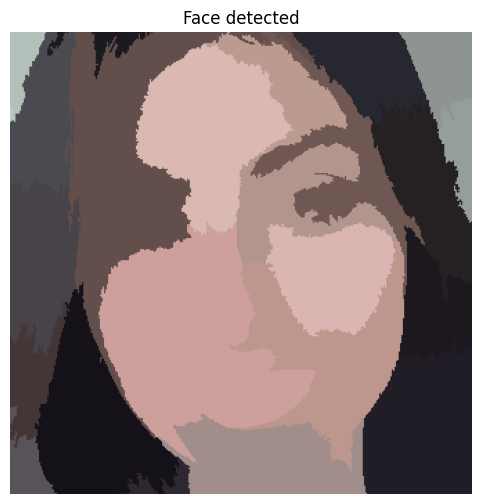

In [12]:
femme = mpimg.imread("face_det9.jpg")

# Obtain the segmentation with default 100 regions
segments = slic(femme)

# Obtain segmented image using label2rgb
segmented_image = label2rgb(segments, femme, kind='avg')

# Detect the faces with multi scale method
detected = detector.detect_multi_scale(img=segmented_image, 
                                       scale_factor=1.2, 
                                       step_ratio=1, 
                                       min_size=(10, 10), max_size=(1000, 1000))

# show_image(segments)
# Show the detected faces
show_detected_face(segmented_image, detected)

11. Exercice

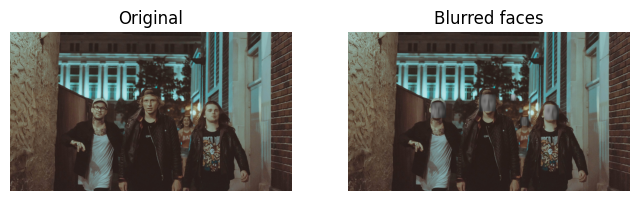

In [13]:
group = mpimg.imread("face_det25.jpg")

group_dup = group.copy()

# Detect the faces
detected = detector.detect_multi_scale(img=group, 
                                       scale_factor=1.2, step_ratio=1, 
                                       min_size=(10, 10), max_size=(100, 100))
# For each detected face
for d in detected:  
    # Obtain the face rectangle from detected coordinates
    face = getFaceRectangle(group_dup,d)
    
    # Apply gaussian filter to extracted face
    blurred_face = gaussian(face, channel_axis=True, sigma = 8, preserve_range=True)
    
    # Merge this blurry face to our final image and show it
    resulting_image = mergeBlurryFace(group, blurred_face,d) 
plot_comparison(group_dup, resulting_image, 'Original','Blurred faces')

12. Exercice

In [14]:
final_boss = mpimg.imread("Graduation-photos-2-girlfriends.jpg")

mask = np.zeros(final_boss.shape[:-1], dtype=bool)
mask[500:510, 700:750] = 1


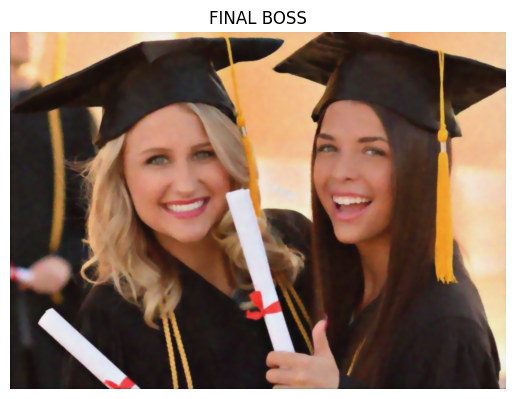

In [57]:
restored_boss = inpaint.inpaint_biharmonic(final_boss, mask, channel_axis=-1)

denoised_boss = denoise_tv_chambolle(restored_boss, weight=0.1, channel_axis=-1)

rotate_boss = rotate(denoised_boss, -22.5)

contour = rotate_boss[214:859, 252:1148]

show_image(contour, "FINAL BOSS")